In [2]:
# Calcul numérique
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from tensorflow.keras.datasets import fashion_mnist

# Construction du réseau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Régularisation
from tensorflow.keras.regularizers import l1, l2, l1_l2
from tensorflow.keras.callbacks import EarlyStopping

# Préparation des données
from sklearn.model_selection import train_test_split

# Évaluation
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

Q1 - Charger et explorer le dataset

In [3]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Forme de X_train :", X_train.shape)
print("Forme de y_train :", y_train.shape)
print("Forme de X_test  :", X_test.shape)
print("Forme de y_test  :", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Forme de X_train : (60000, 28, 28)
Forme de y_train : (60000,)
Forme de X_test  : (10000, 28, 28)
Forme de y_test  : (10000,)


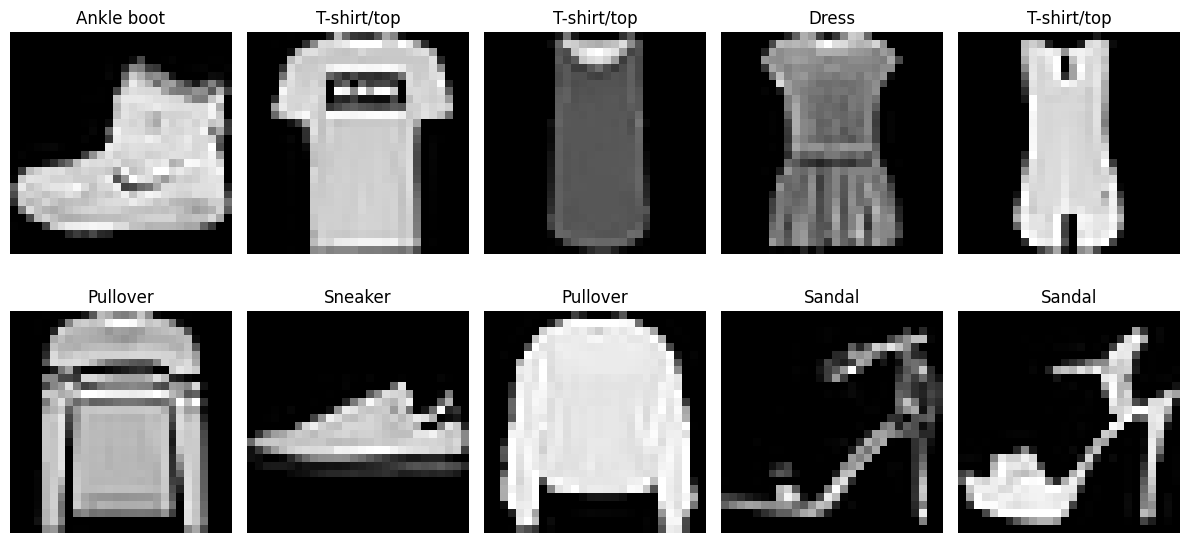

In [4]:
# Affichage de quelques images
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(12,6))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

Q2 - Préparation des données

In [5]:
# 1) Normalisation des pixels entre 0 et 1
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

# 2) Transformation des images 28x28 en vecteurs de taille 784
X_train = X_train.reshape(X_train.shape[0], 28 * 28)
X_test  = X_test.reshape(X_test.shape[0], 28 * 28)

# 3) Création d'un ensemble de validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# Vérification des dimensions
print("Forme de X_train_final :", X_train_final.shape)
print("Forme de y_train_final :", y_train_final.shape)
print("Forme de X_val         :", X_val.shape)
print("Forme de y_val         :", y_val.shape)
print("Forme de X_test        :", X_test.shape)
print("Forme de y_test        :", y_test.shape)

Forme de X_train_final : (48000, 784)
Forme de y_train_final : (48000,)
Forme de X_val         : (12000, 784)
Forme de y_val         : (12000,)
Forme de X_test        : (10000, 784)
Forme de y_test        : (10000,)


Q3 - Construction du modèle de base sans régularisation

In [6]:
model_baseline = Sequential([
    Dense(256, activation="relu", input_shape=(784,)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model_baseline.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_baseline.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Q4 - Entraînement du modèle de base

In [7]:
history_baseline = model_baseline.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=128,
    verbose=1
)

Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8059 - loss: 0.5465 - val_accuracy: 0.8558 - val_loss: 0.4043
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8591 - loss: 0.3854 - val_accuracy: 0.8647 - val_loss: 0.3687
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8747 - loss: 0.3407 - val_accuracy: 0.8736 - val_loss: 0.3532
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8842 - loss: 0.3113 - val_accuracy: 0.8736 - val_loss: 0.3500
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8926 - loss: 0.2901 - val_accuracy: 0.8767 - val_loss: 0.3480
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8977 - loss: 0.2727 - val_accuracy: 0.8807 - val_loss: 0.3458
Epoch 7/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9030 - loss: 0.2583 - val_accuracy: 0.8780 - val_loss: 0.3532
Epoch 8/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9070 - loss: 0.2452 - val_accuracy: 0.

Q5 - Analyse des performances du modèle de base

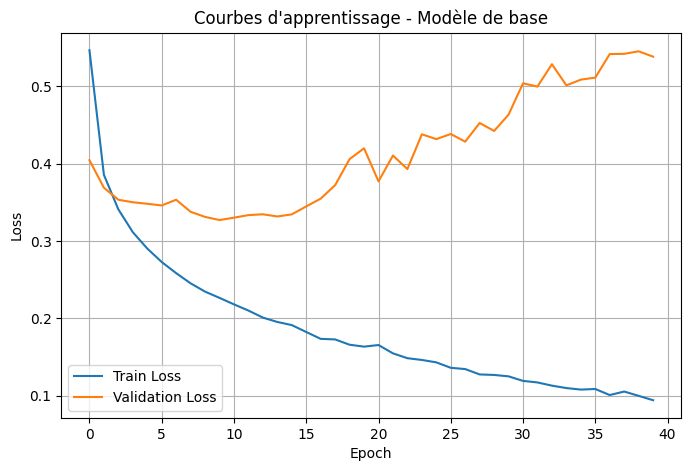

In [8]:
# 1) Courbes d'apprentissage : loss
plt.figure(figsize=(8,5))
plt.plot(history_baseline.history["loss"], label="Train Loss")
plt.plot(history_baseline.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Courbes d'apprentissage - Modèle de base")
plt.legend()
plt.grid(True)
plt.show()

***J'observe que le train Loss diminue progressivement au fil des epochs, donc le modele apprend bien les donnees d'entrainement. Cependant, la validation Loss diminue au debut puis il augmente apres quelques epochs. Cela indique un Surapprentissage (Overfitting)***

In [9]:
# 2) Évaluation sur l'ensemble de test
test_loss, test_accuracy = model_baseline.evaluate(X_test, y_test, verbose=0)
print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

Test Loss     : 0.5538032054901123
Test Accuracy : 0.8824999928474426


In [10]:
# 3) Prédiction des classes sur l'ensemble de test
y_pred_proba = model_baseline.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


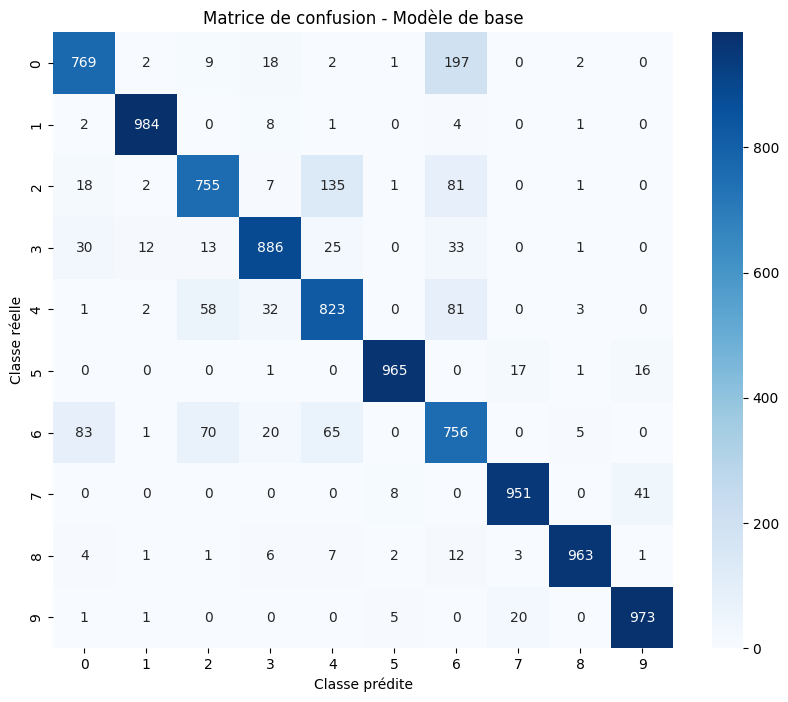

In [11]:
# 4) Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion - Modèle de base")
plt.show()

In [12]:
# 5) Classification report
print("Classification Report - Modèle de base\n")
print(classification_report(y_test, y_pred, target_names=class_names))

Classification Report - Modèle de base

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.77      0.81      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.83      0.76      0.79      1000
       Dress       0.91      0.89      0.90      1000
        Coat       0.78      0.82      0.80      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.65      0.76      0.70      1000
     Sneaker       0.96      0.95      0.96      1000
         Bag       0.99      0.96      0.97      1000
  Ankle boot       0.94      0.97      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



Q6 - Régularisation par Early Stopping

In [13]:
model_early = Sequential([
    Dense(256, activation="relu", input_shape=(784,)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model_early.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_early = model_early.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=128,
    verbose=1,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8066 - loss: 0.5518 - val_accuracy: 0.8304 - val_loss: 0.4518
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8586 - loss: 0.3874 - val_accuracy: 0.8562 - val_loss: 0.3860
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8747 - loss: 0.3431 - val_accuracy: 0.8681 - val_loss: 0.3555
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8835 - loss: 0.3148 - val_accuracy: 0.8740 - val_loss: 0.3441
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8899 - loss: 0.2954 - val_accuracy: 0.8785 - val_loss: 0.3379
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8968 - loss: 0.2777 - val_accuracy: 0.8822 - val_loss: 0.3322
Epoch 7/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9015 - loss: 0.2631 - val_accuracy: 0.8861 - val_loss: 0.3222
Epoch 8/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9072 - loss: 0.2485 - val_accuracy: 0.

Q7 - Analyse du modèle avec Early Stopping

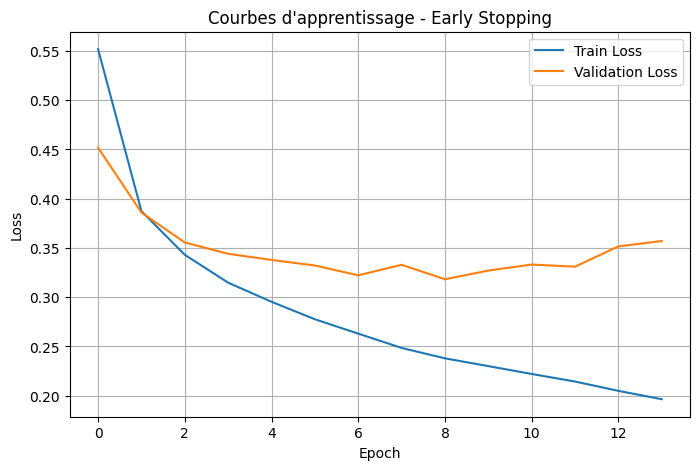

In [14]:
# 1) Courbes d'apprentissage
plt.figure(figsize=(8,5))
plt.plot(history_early.history["loss"], label="Train Loss")
plt.plot(history_early.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Courbes d'apprentissage - Early Stopping")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# 2) Évaluation sur test
test_loss_early, test_accuracy_early = model_early.evaluate(X_test, y_test, verbose=0)
print("Test Loss     :", test_loss_early)
print("Test Accuracy :", test_accuracy_early)

Test Loss     : 0.3543563783168793
Test Accuracy : 0.8788999915122986


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


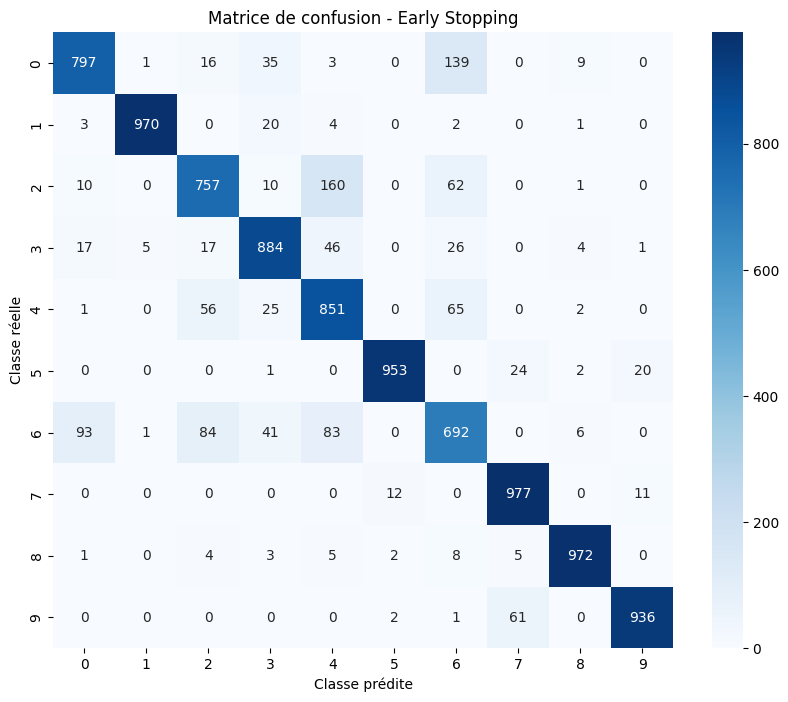

In [16]:
# 3) Matrice de confusion
y_pred_prob_early = model_early.predict(X_test)
y_pred_early = np.argmax(y_pred_prob_early, axis=1)

cm_early = confusion_matrix(y_test, y_pred_early)

plt.figure(figsize=(10,8))
sns.heatmap(cm_early, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion - Early Stopping")
plt.show()

In [17]:
# 4) Classification report
print("Classification Report - Early Stopping\n")
print(classification_report(y_test, y_pred_early, target_names=class_names))

Classification Report - Early Stopping

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.80      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.81      0.76      0.78      1000
       Dress       0.87      0.88      0.88      1000
        Coat       0.74      0.85      0.79      1000
      Sandal       0.98      0.95      0.97      1000
       Shirt       0.70      0.69      0.69      1000
     Sneaker       0.92      0.98      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.97      0.94      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



***Les courbes d’apprentissage montrent que le modèle de base présente un surapprentissage, car la validation loss augmente alors que la train loss continue de diminuer.
Le modèle avec Early Stopping permet de limiter le surapprentissage en arrêtant l’entraînement lorsque la validation loss cesse de s’améliorer.
Ainsi, Early Stopping améliore la capacité de généralisation du modèle et permet d’éviter un apprentissage excessif.***

Q8 - Régularisation par pénalisation des poids

In [18]:
#L1
model_l1 = Sequential([
    Dense(256, activation="relu", input_shape=(784,), kernel_regularizer=l1(0.001)),
    Dense(128, activation="relu", kernel_regularizer=l1(0.001)),
    Dense(64, activation="relu", kernel_regularizer=l1(0.001)),
    Dense(10, activation="softmax")
])

model_l1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_l1 = model_l1.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=128,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7597 - loss: 3.1811 - val_accuracy: 0.8019 - val_loss: 1.4866
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8019 - loss: 1.2780 - val_accuracy: 0.8112 - val_loss: 1.1190
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8130 - loss: 1.0304 - val_accuracy: 0.8248 - val_loss: 0.9349
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8197 - loss: 0.9155 - val_accuracy: 0.8277 - val_loss: 0.8527
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8241 - loss: 0.8501 - val_accuracy: 0.8305 - val_loss: 0.8025
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8275 - loss: 0.8077 - val_accuracy: 0.8344 - val_loss: 0.7661
Epoch 7/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8306 - loss: 0.7754 - val_accuracy: 0.8357 - val_loss: 0.7384
Epoch 8/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8326 - loss: 0.7507 - val_accuracy: 0.

In [19]:
#L2
model_l2 = Sequential([
    Dense(256, activation="relu", input_shape=(784,), kernel_regularizer=l2(0.001)),
    Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
    Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
    Dense(10, activation="softmax")
])

model_l2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_l2 = model_l2.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=128,
    verbose=1
)

Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8012 - loss: 0.9558 - val_accuracy: 0.8357 - val_loss: 0.7370
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8494 - loss: 0.6678 - val_accuracy: 0.8427 - val_loss: 0.6424
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8600 - loss: 0.5852 - val_accuracy: 0.8553 - val_loss: 0.5745
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8643 - loss: 0.5406 - val_accuracy: 0.8516 - val_loss: 0.5603
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8690 - loss: 0.5101 - val_accuracy: 0.8559 - val_loss: 0.5347
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8726 - loss: 0.4879 - val_accuracy: 0.8569 - val_loss: 0.5155
Epoch 7/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8762 - loss: 0.4694 - val_accuracy: 0.8616 - val_loss: 0.4979
Epoch 8/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8782 - loss: 0.4568 - val_accuracy: 0.

In [20]:
#L1_L2
model_elastic = Sequential([
    Dense(256, activation="relu", input_shape=(784,), kernel_regularizer=l1_l2(l1=0.0001, l2=0.001)),
    Dense(128, activation="relu", kernel_regularizer=l1_l2(l1=0.0001, l2=0.001)),
    Dense(64, activation="relu", kernel_regularizer=l1_l2(l1=0.0001, l2=0.001)),
    Dense(10, activation="softmax")
])

model_elastic.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_elastic = model_elastic.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=128,
    verbose=1
)

Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7981 - loss: 1.4559 - val_accuracy: 0.8416 - val_loss: 1.0215
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8405 - loss: 0.9136 - val_accuracy: 0.8456 - val_loss: 0.8244
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8479 - loss: 0.7671 - val_accuracy: 0.8461 - val_loss: 0.7330
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8516 - loss: 0.6948 - val_accuracy: 0.8463 - val_loss: 0.6822
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8567 - loss: 0.6453 - val_accuracy: 0.8544 - val_loss: 0.6269
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8592 - loss: 0.6099 - val_accuracy: 0.8569 - val_loss: 0.5988
Epoch 7/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8628 - loss: 0.5811 - val_accuracy: 0.8587 - val_loss: 0.5815
Epoch 8/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8654 - loss: 0.5568 - val_accuracy: 0.

Q9 - Analyse des modèles régularisés

In [21]:
def analyser_modele(model, history, X_test, y_test, nom_modele):
    # 1) Courbes
    plt.figure(figsize=(8,5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Courbes d'apprentissage - {nom_modele}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2) Évaluation
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"{nom_modele} - Test Loss     :", test_loss)
    print(f"{nom_modele} - Test Accuracy :", test_accuracy)

    # 3) Prédictions + matrice de confusion
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Classe prédite")
    plt.ylabel("Classe réelle")
    plt.title(f"Matrice de confusion - {nom_modele}")
    plt.show()

    # 4) Classification report
    print(f"Classification Report - {nom_modele}\n")
    print(classification_report(y_test, y_pred, target_names=class_names))

    return test_loss, test_accuracy

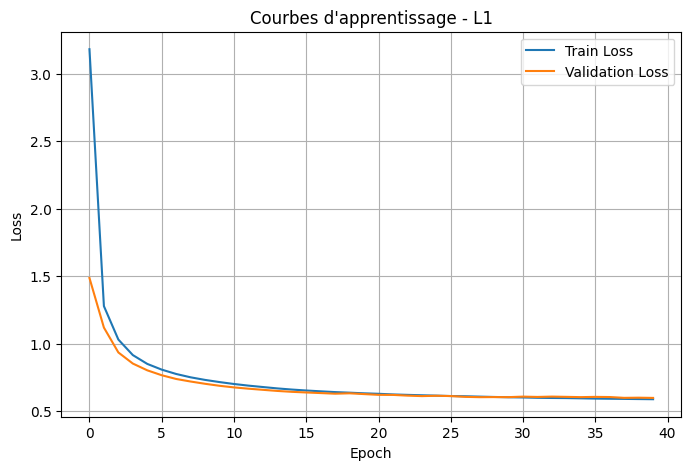

L1 - Test Loss     : 0.6311830878257751
L1 - Test Accuracy : 0.8382999897003174
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


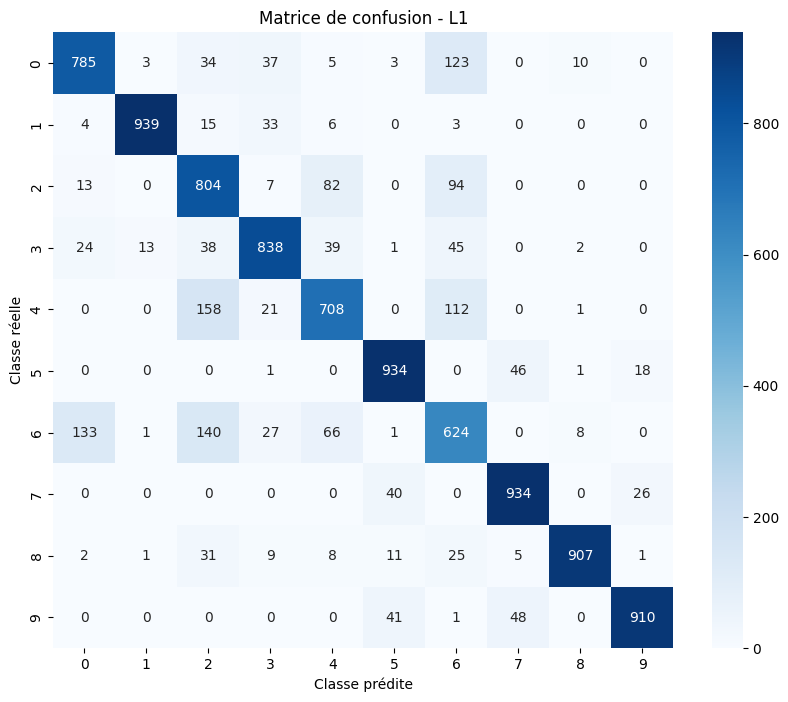

Classification Report - L1

              precision    recall  f1-score   support

 T-shirt/top       0.82      0.79      0.80      1000
     Trouser       0.98      0.94      0.96      1000
    Pullover       0.66      0.80      0.72      1000
       Dress       0.86      0.84      0.85      1000
        Coat       0.77      0.71      0.74      1000
      Sandal       0.91      0.93      0.92      1000
       Shirt       0.61      0.62      0.62      1000
     Sneaker       0.90      0.93      0.92      1000
         Bag       0.98      0.91      0.94      1000
  Ankle boot       0.95      0.91      0.93      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



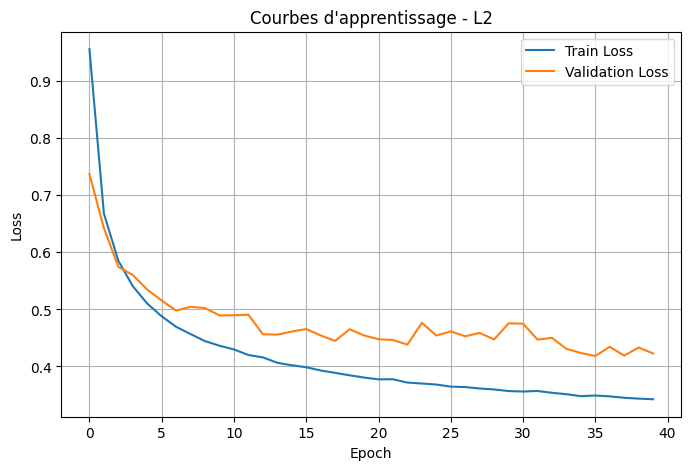

L2 - Test Loss     : 0.459044486284256
L2 - Test Accuracy : 0.8693000078201294
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


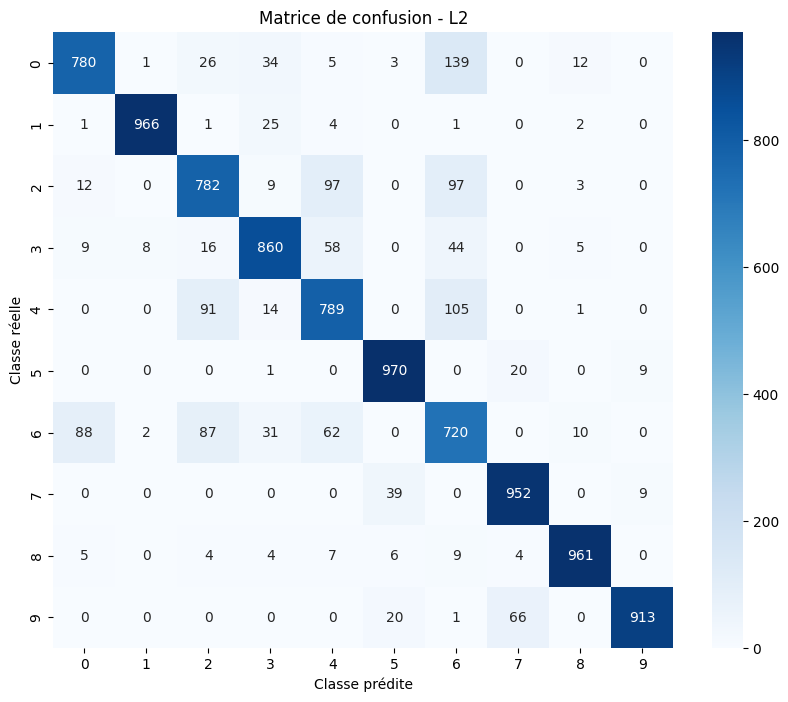

Classification Report - L2

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.78      0.82      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.78      0.78      0.78      1000
       Dress       0.88      0.86      0.87      1000
        Coat       0.77      0.79      0.78      1000
      Sandal       0.93      0.97      0.95      1000
       Shirt       0.65      0.72      0.68      1000
     Sneaker       0.91      0.95      0.93      1000
         Bag       0.97      0.96      0.96      1000
  Ankle boot       0.98      0.91      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



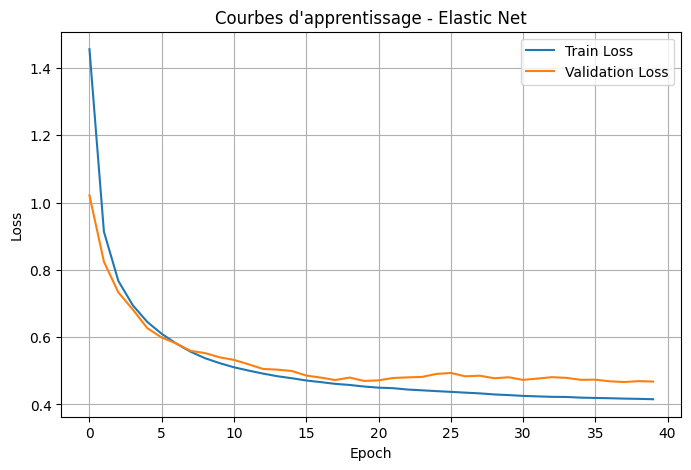

Elastic Net - Test Loss     : 0.5008074641227722
Elastic Net - Test Accuracy : 0.8622999787330627
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


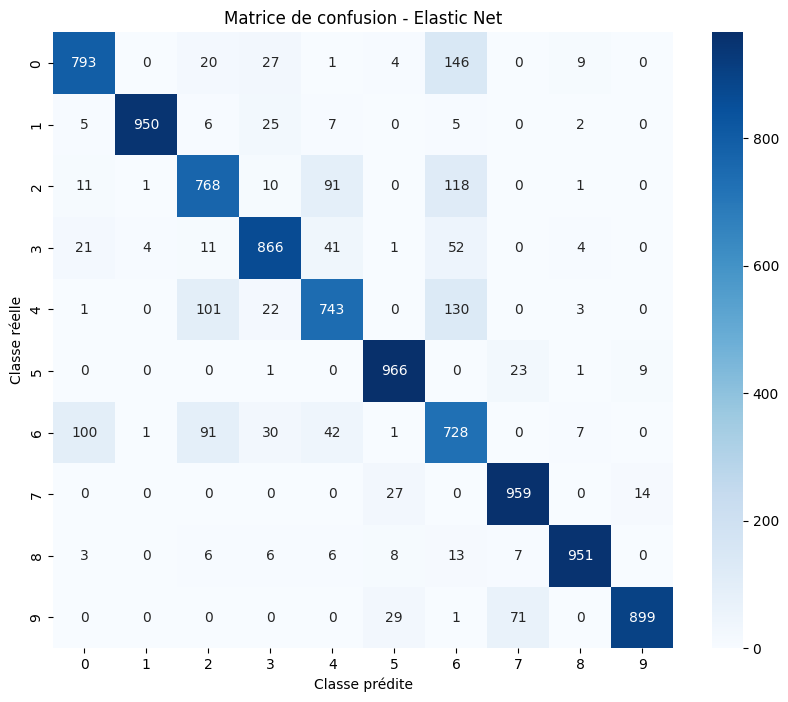

Classification Report - Elastic Net

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.79      0.82      1000
     Trouser       0.99      0.95      0.97      1000
    Pullover       0.77      0.77      0.77      1000
       Dress       0.88      0.87      0.87      1000
        Coat       0.80      0.74      0.77      1000
      Sandal       0.93      0.97      0.95      1000
       Shirt       0.61      0.73      0.66      1000
     Sneaker       0.90      0.96      0.93      1000
         Bag       0.97      0.95      0.96      1000
  Ankle boot       0.98      0.90      0.94      1000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000



In [22]:
# Analyse du modele L1
test_loss_l1, test_accuracy_l1 = analyser_modele(
    model_l1, history_l1, X_test, y_test, "L1")

# Analyse du modele L2
test_loss_l2, test_accuracy_l2 = analyser_modele(
    model_l2, history_l2, X_test, y_test, "L2")

# Analyse du modele Elastic Net
test_loss_elastic, test_accuracy_elastic = analyser_modele(
    model_elastic, history_elastic, X_test, y_test, "Elastic Net")


***Les résultats montrent que la régularisation L1 réduit davantage les performances du modèle. La régularisation L2 améliore légèrement les résultats par rapport à L1. Elastic Net et Early Stopping offrent de meilleures performances et une meilleure généralisation du modèle.
Ainsi, Early Stopping apparaît comme la technique de régularisation la plus efficace dans cette expérience, car elle obtient de très bonnes performances tout en limitant le surapprentissage.***

Q10 - aide à la décision

In [24]:
results = pd.DataFrame({
    "Model": ["Baseline", "EarlyStopping", "L1", "L2", "ElasticNet"],
    "Test Loss": [
        test_loss,
        test_loss_early,
        test_loss_l1,
        test_loss_l2,
        test_loss_elastic
    ],
    "Test Accuracy": [
        test_accuracy,
        test_accuracy_early,
        test_accuracy_l1,
        test_accuracy_l2,
        test_accuracy_elastic
    ]
})

print(results)

           Model  Test Loss  Test Accuracy
0       Baseline   0.553803         0.8825
1  EarlyStopping   0.354356         0.8789
2             L1   0.631183         0.8383
3             L2   0.459044         0.8693
4     ElasticNet   0.500807         0.8623


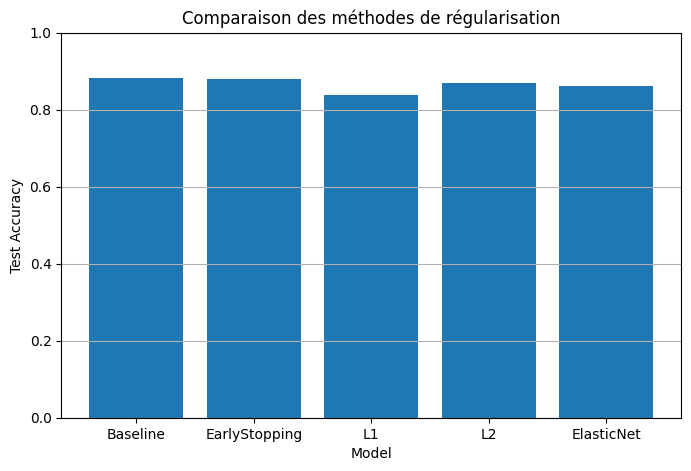

In [25]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Test Accuracy"])
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("Comparaison des méthodes de régularisation")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

***D’après le tableau comparatif et le graphique, Early Stopping, L2 et Elastic Net offrent des performances proches et relativement élevées sur l’ensemble de test, tandis que L1 donne les performances les plus faibles.
Early Stopping permet d’arrêter l’entraînement lorsque la performance sur les
données de validation cesse de s’améliorer, ce qui aide à limiter le surapprentissage.
L1 pénalise fortement les poids et peut réduire certains paramètres à zéro, mais cela peut parfois diminuer les performances.
L2 pénalise les poids élevés et aide à stabiliser l’apprentissage.
Elastic Net combine les avantages de L1 et L2 pour améliorer la généralisation du modèle.***